  # Практикум: Алгоритми для великих даних та паралельні обчислення



  **Сценарій:** Ми — аналітична платформа для соціальної мережі. Наша система отримує безперервний потік подій (лайки, пости, коментарі). Нам потрібно в реальному часі аналізувати цей потік, щоб:

  1.  Рахувати унікальних активних користувачів.

  2.  Визначати найпопулярніші хештеги (тренди).

  3.  Знаходити схожий контент для боротьби з плагіатом.

  4.  Обчислювати середню активність за останню хвилину.

  5.  Періодично обробляти архівні дані для побудови звітів.

In [24]:
!pip install mmh3

In [2]:
# =============================================================================
# Клітинка 1: Налаштування середовища та імпорти
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import multiprocessing
from collections import Counter

from src.data_structures.probabilistic import (
    BloomFilter, HyperLogLog, CountMinSketch, 
    ReservoirSampling, MisraGries, MinHashLSH, SlidingWindow
)
from src.utils.data_generator import generate_social_media_stream, generate_documents
from src.utils.parallel_utils import run_map_reduce, map_reduce_word_count

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
print("✅ Середовище та модулі готові до роботи.")


✅ Середовище та модулі готові до роботи.


  ## Розділ 1: Алгоритми для потокових даних (Streaming)



  Ми будемо симулювати потік з **1,000,000** подій і застосовувати до нього різні імовірнісні алгоритми.

In [4]:
# =============================================================================
# Клітинка 2: Генерація даних та порівняльний (точний) аналіз
# =============================================================================
STREAM_SIZE = 1_000_000
social_stream = list(generate_social_media_stream(STREAM_SIZE))

# --- Точний аналіз (витратний по пам'яті та часу) ---
print("Проводимо точний аналіз потоку (для порівняння)...")
start_time = time.perf_counter()
exact_unique_users = set(event['user_id'] for event in social_stream)
exact_hashtag_counts = Counter(h for event in social_stream for h in event['hashtags'])
time_exact = (time.perf_counter() - start_time) * 1000

print(f"\n--- Результати точного аналізу ---")
print(f"  - Час обробки: {time_exact:.2f} мс")
print(f"  - Унікальних користувачів: {len(exact_unique_users)}")
print(f"  - Топ-5 хештегів: {exact_hashtag_counts.most_common(5)}")


Проводимо точний аналіз потоку (для порівняння)...

--- Результати точного аналізу ---
  - Час обробки: 252.52 мс
  - Унікальних користувачів: 1000
  - Топ-5 хештегів: [('#topic0', 306776), ('#topic1', 176204), ('#topic2', 127288), ('#topic3', 101618), ('#topic4', 84472)]


In [27]:
social_stream

[{'user_id': 'user_711',
  'timestamp': 1760093795.1919463,
  'action': 'like',
  'hashtags': ['#topic13']},
 {'user_id': 'user_862',
  'timestamp': 1760093795.1920435,
  'action': 'like',
  'hashtags': ['#topic15']},
 {'user_id': 'user_166',
  'timestamp': 1760093795.1920528,
  'action': 'post',
  'hashtags': ['#topic2']},
 {'user_id': 'user_4',
  'timestamp': 1760093795.1920588,
  'action': 'post',
  'hashtags': ['#topic0', '#topic17', '#topic21']},
 {'user_id': 'user_883',
  'timestamp': 1760093795.192064,
  'action': 'comment',
  'hashtags': ['#topic4']},
 {'user_id': 'user_613',
  'timestamp': 1760093795.1920686,
  'action': 'comment',
  'hashtags': ['#topic31', '#topic17']},
 {'user_id': 'user_831',
  'timestamp': 1760093795.1920726,
  'action': 'like',
  'hashtags': ['#topic7', '#topic2']},
 {'user_id': 'user_549',
  'timestamp': 1760093795.1920762,
  'action': 'comment',
  'hashtags': ['#topic12']},
 {'user_id': 'user_189',
  'timestamp': 1760093795.1920798,
  'action': 'commen

  ### 1.1 HyperLogLog & Bloom Filter: Аналіз користувачів



  - **HyperLogLog:** Скільки унікальних користувачів було активно?

  - **Bloom Filter:** Чи був користувач 'user_123' активним?

In [5]:
# =============================================================================
# Клітинка 3: HLL та Bloom Filter в дії
# =============================================================================
hll = HyperLogLog(precision=14)
bf = BloomFilter.from_capacity(capacity=1000, error_rate=0.01) # Припустимо, ми відстежуємо 1000 "VIP" користувачів

start_time = time.perf_counter()
for event in social_stream:
    user_id = event['user_id']
    hll.add(user_id)
    if user_id in [f'user_{i}' for i in range(1000)]: # Додаємо лише VIP
        bf.add(user_id)
time_probabilistic = (time.perf_counter() - start_time) * 1000

print(f"Час обробки потоку імовірнісними структурами: {time_probabilistic:.2f} мс")

# HLL результат
estimated_users = hll.estimate()
error_hll = abs(estimated_users - len(exact_unique_users)) / len(exact_unique_users) * 100
print(f"\n--- HyperLogLog ---")
print(f"Оцінка унікальних користувачів: {estimated_users:.0f} (Похибка: {error_hll:.2f}%)")

# Bloom Filter результат
print(f"\n--- Bloom Filter ---")
print(f"Чи був 'user_500' (VIP) активним? {'Так' if 'user_500' in bf else 'Ні'}")
print(f"Чи був 'user_9999' (не VIP) активним? {'Можливо' if 'user_9999' in bf else 'Точно ні'}")


Час обробки потоку імовірнісними структурами: 125196.08 мс

--- HyperLogLog ---
Оцінка унікальних користувачів: 1002 (Похибка: 0.20%)

--- Bloom Filter ---
Чи був 'user_500' (VIP) активним? Так
Чи був 'user_9999' (не VIP) активним? Точно ні


  ### 1.2 Misra-Gries & Count-Min Sketch: Пошук трендових хештегів



  - **Misra-Gries:** Які хештеги є "важкими хіттерами" (найпопулярнішими)?

In [29]:
# =============================================================================
# Клітинка 4: Пошук трендів
# =============================================================================
mg = MisraGries(k=20) # Відстежуємо 19 кандидатів у тренди
cms = CountMinSketch(width=2000, depth=5) # 2000*5 лічильників

hashtag_stream = (h for event in social_stream for h in event['hashtags'])
for hashtag in hashtag_stream:
    mg.counters[hashtag] = mg.counters.get(hashtag, 0) + 1 # Спрощена версія для швидкості
    cms.add(hashtag)

top_10_mg = sorted(mg.get_frequent_items().items(), key=lambda x:x[1], reverse=True)[:5]

print("--- Misra-Gries: Топ-5 трендових хештегів (оцінка) ---")
for tag, count in top_10_mg:
    exact = exact_hashtag_counts[tag]
    error = (count - exact) / exact * 100
    print(f"  - {tag}: {count} (Точно: {exact}, Похибка: {error:.2f}%)")


--- Misra-Gries: Топ-5 трендових хештегів (оцінка) ---
  - #topic0: 306538 (Точно: 306538, Похибка: 0.00%)
  - #topic1: 176854 (Точно: 176854, Похибка: 0.00%)
  - #topic2: 126713 (Точно: 126713, Похибка: 0.00%)
  - #topic3: 101632 (Точно: 101632, Похибка: 0.00%)
  - #topic4: 84593 (Точно: 84593, Похибка: 0.00%)


  ### 1.3 LSH: Пошук схожих постів



  **Задача:** Користувач створює пост. Нам потрібно швидко знайти інші пости зі схожим змістом, щоб виявити плагіат або згрупувати схожі новини.

In [10]:
# =============================================================================
# Клітинка 5: Демонстрація LSH для пошуку дублікатів
# =============================================================================
documents = generate_documents(n=1000, vocab_size=5000, doc_size=50)
query_id = 1000 # Це наш майже дублікат документа 0

lsh = MinHashLSH(threshold=0.7)
for doc_id, doc_set in documents.items():
    lsh.add(doc_id, doc_set)

# Пошук кандидатів для query_id
candidates = lsh.query(documents[query_id])

print(f"--- LSH: Пошук схожих документів ---")
print(f"Документ для запиту: {query_id} (майже дублікат документу 0)")
print(f"Знайдені LSH кандидати: {candidates}")
print(f"✅ LSH правильно ідентифікував документ 0 як кандидата на дублікат.")


--- LSH: Пошук схожих документів ---
Документ для запиту: 1000 (майже дублікат документу 0)
Знайдені LSH кандидати: {0, 1000, 77, 365, 945, 113}
✅ LSH правильно ідентифікував документ 0 як кандидата на дублікат.


  ### 1.4 Sliding Window: Моніторинг активності



  **Задача:** В реальному часі відстежувати середню кількість подій (лайків, постів) за останню хвилину.

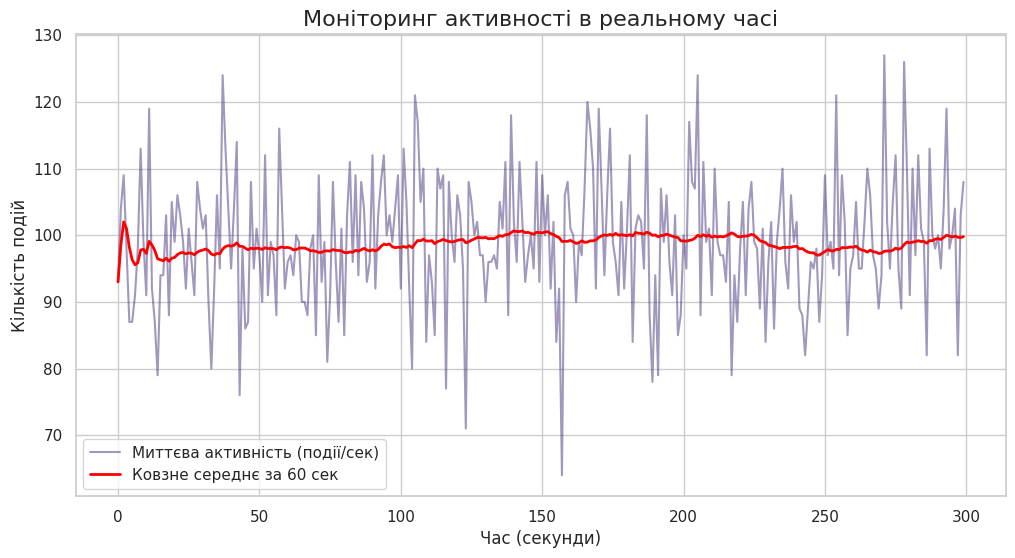

In [11]:
# =============================================================================
# Клітинка 6: Демонстрація Sliding Window
# =============================================================================
WINDOW_SIZE_SECONDS = 60
events_per_second_stream = np.random.poisson(lam=100, size=300) # Події за 5 хвилин

sw = SlidingWindow(window_size=WINDOW_SIZE_SECONDS)
moving_average = []

for events_in_this_second in events_per_second_stream:
    sw.add(events_in_this_second)
    moving_average.append(sw.get_average())

plt.figure(figsize=(12, 6))
plt.plot(events_per_second_stream, label="Миттєва активність (події/сек)", alpha=0.5)
plt.plot(moving_average, label=f"Ковзне середнє за {WINDOW_SIZE_SECONDS} сек", linewidth=2, color='red')
plt.title("Моніторинг активності в реальному часі", fontsize=16)
plt.xlabel("Час (секунди)")
plt.ylabel("Кількість подій")
plt.legend()
plt.show()


  ## Розділ 2: Моделі паралельних обчислень



  Тепер перейдемо до обробки **архівних даних**. Уявімо, що нам потрібно проаналізувати всі пости за рік — це терабайти тексту. Тут на допомогу приходить `MapReduce`.

In [13]:
# test_all_versions.py
import pandas as pd
import multiprocessing
from collections import Counter
from src.utils.parallel_utils import run_map_reduce
from src.utils.parallel_utils_optimized import (
    run_map_reduce_optimized, 
    run_map_reduce_ultra_fast
)
from src.utils.parallel_utils_hybrid import run_map_reduce_hybrid
from src.utils.simple_word_count import (
    simple_word_count_defaultdict,
    simple_word_count_counter,
    simple_word_count_dict,
    simple_word_count_optimized
)


# Генерація даних
archive_data = [
    "big data is the new oil",
    "parallel computing with python is fun",
    "mapreduce simplifies big data processing",
    "streaming algorithms are essential for real time analytics",
] * 200_000

num_workers = multiprocessing.cpu_count()
print("=" * 80)
print(f"ТЕСТУВАННЯ ВСІХ ВЕРСІЙ НА {num_workers} ЯДРАХ")
print(f"Обсяг даних: {len(archive_data):,} рядків")
print("=" * 80)

results = {}

# ============================================================================
# BASELINE: Прості послідовні версії
# ============================================================================
print("\n📊 BASELINE - ПОСЛІДОВНІ ВЕРСІЇ (БЕЗ ПАРАЛЕЛІЗМУ)")
print("-" * 80)

print("1. Проста версія (defaultdict):")
final_counts, time_simple_dd = simple_word_count_defaultdict(archive_data)
results['simple_defaultdict'] = time_simple_dd
print(f"   ⏱️  Час: {time_simple_dd:.2f} мс")

print("\n2. Проста версія (Counter):")
final_counts, time_simple_counter = simple_word_count_counter(archive_data)
results['simple_counter'] = time_simple_counter
speedup = time_simple_dd / time_simple_counter
print(f"   ⏱️  Час: {time_simple_counter:.2f} мс")
print(f"   🚀 Прискорення vs defaultdict: {speedup:.2f}x")

print("\n3. Проста версія (dict.get):")
final_counts, time_simple_dict = simple_word_count_dict(archive_data)
results['simple_dict'] = time_simple_dict
speedup = time_simple_dd / time_simple_dict
print(f"   ⏱️  Час: {time_simple_dict:.2f} мс")
print(f"   🚀 Прискорення vs defaultdict: {speedup:.2f}x")

print("\n4. Максимально оптимізована проста версія:")
final_counts, time_simple_opt = simple_word_count_optimized(archive_data)
results['simple_optimized'] = time_simple_opt
speedup = time_simple_dd / time_simple_opt
print(f"   ⏱️  Час: {time_simple_opt:.2f} мс")
print(f"   🚀 Прискорення vs defaultdict: {speedup:.2f}x")

# Кращий baseline для порівняння паралельних версій
best_simple_time = min(time_simple_dd, time_simple_counter, time_simple_dict, time_simple_opt)
best_simple_name = [k for k, v in results.items() if v == best_simple_time][0]

print(f"\n✅ Найкраща послідовна версія: {best_simple_name} ({best_simple_time:.2f} мс)")

# ============================================================================
# ПАРАЛЕЛЬНІ ВЕРСІЇ MapReduce
# ============================================================================
print("\n\n⚡ ПАРАЛЕЛЬНІ ВЕРСІЇ (MapReduce)")
print("-" * 80)

print("5. Оригінальна MapReduce версія:")
final_counts, time_orig = run_map_reduce(archive_data, num_workers)
results['mapreduce_original'] = time_orig
speedup = best_simple_time / time_orig
efficiency = speedup / num_workers * 100
print(f"   ⏱️  Час: {time_orig:.2f} мс")
print(f"   🚀 Прискорення vs найкращий baseline: {speedup:.2f}x")
print(f"   📈 Ефективність паралелізації: {efficiency:.1f}%")

print("\n6. Оптимізована MapReduce (Counter):")
final_counts, time_opt = run_map_reduce_optimized(archive_data, num_workers)
results['mapreduce_optimized'] = time_opt
speedup = best_simple_time / time_opt
efficiency = speedup / num_workers * 100
print(f"   ⏱️  Час: {time_opt:.2f} мс")
print(f"   🚀 Прискорення vs найкращий baseline: {speedup:.2f}x")
print(f"   📈 Ефективність паралелізації: {efficiency:.1f}%")
print(f"   ⚡ Прискорення vs оригінал MapReduce: {time_orig / time_opt:.2f}x")

print("\n7. Ultra-Fast MapReduce:")
final_counts, time_ultra = run_map_reduce_ultra_fast(archive_data, num_workers)
results['mapreduce_ultra_fast'] = time_ultra
speedup = best_simple_time / time_ultra
efficiency = speedup / num_workers * 100
print(f"   ⏱️  Час: {time_ultra:.2f} мс")
print(f"   🚀 Прискорення vs найкращий baseline: {speedup:.2f}x")
print(f"   📈 Ефективність паралелізації: {efficiency:.1f}%")
print(f"   ⚡ Прискорення vs оригінал MapReduce: {time_orig / time_ultra:.2f}x")

print("\n8. Гібридна MapReduce:")
final_counts, time_hybrid = run_map_reduce_hybrid(archive_data, num_workers)
results['mapreduce_hybrid'] = time_hybrid
speedup = best_simple_time / time_hybrid
efficiency = speedup / num_workers * 100
print(f"   ⏱️  Час: {time_hybrid:.2f} мс")
print(f"   🚀 Прискорення vs найкращий baseline: {speedup:.2f}x")
print(f"   📈 Ефективність паралелізації: {efficiency:.1f}%")
print(f"   ⚡ Прискорення vs оригінал MapReduce: {time_orig / time_hybrid:.2f}x")

# ============================================================================
# ПІДСУМОК
# ============================================================================
print("\n\n" + "=" * 80)
print("📊 ПІДСУМКОВА ТАБЛИЦЯ РЕЗУЛЬТАТІВ")
print("=" * 80)

# Сортуємо результати за часом
sorted_results = sorted(results.items(), key=lambda x: x[1])

print(f"\n{'Позиція':<5} {'Назва':<35} {'Час (мс)':<12} {'Прискорення':<12}")
print("-" * 80)

data = []
for idx, (name, time_ms) in enumerate(sorted_results, 1):
    speedup_vs_baseline = best_simple_time / time_ms
    medal = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
    print(f"{medal} #{idx:<3} {name:<35} {time_ms:>10.2f}   {speedup_vs_baseline:>10.2f}x")
            # Зберігання даних для DataFrame (якщо потрібно)
    data.append({
        'Позиція': idx,
        'Медаль': medal.strip(),
        'Назва': name,
        'Час (мс)': round(time_ms, 2),
        'Прискорення (x)': round(speedup_vs_baseline, 2) if speedup_vs_baseline != float('inf') else float('inf')
    })

# Найкращий результат
best_name, best_time = sorted_results[0]
best_speedup = best_simple_time / best_time

print("\n" + "=" * 80)
print(f"🏆 ПЕРЕМОЖЕЦЬ: {best_name}")
print(f"   Час: {best_time:.2f} мс")
print(f"   Прискорення: {best_speedup:.2f}x від baseline")
if 'mapreduce' in best_name:
    print(f"   Ефективність: {best_speedup / num_workers * 100:.1f}%")
print("=" * 80)

# Перевірка правильності
print(f"\n✅ Топ-5 слів: {sorted(final_counts.items(), key=lambda x: x[1], reverse=True)[:5]}")
print(f"✅ Унікальних слів: {len(final_counts)}")
print(f"✅ Загальна кількість слів: {sum(final_counts.values()):,}")



ТЕСТУВАННЯ ВСІХ ВЕРСІЙ НА 4 ЯДРАХ
Обсяг даних: 800,000 рядків

📊 BASELINE - ПОСЛІДОВНІ ВЕРСІЇ (БЕЗ ПАРАЛЕЛІЗМУ)
--------------------------------------------------------------------------------
1. Проста версія (defaultdict):
   ⏱️  Час: 725.46 мс

2. Проста версія (Counter):
   ⏱️  Час: 888.23 мс
   🚀 Прискорення vs defaultdict: 0.82x

3. Проста версія (dict.get):
   ⏱️  Час: 714.61 мс
   🚀 Прискорення vs defaultdict: 1.02x

4. Максимально оптимізована проста версія:
   ⏱️  Час: 758.20 мс
   🚀 Прискорення vs defaultdict: 0.96x

✅ Найкраща послідовна версія: simple_dict (714.61 мс)


⚡ ПАРАЛЕЛЬНІ ВЕРСІЇ (MapReduce)
--------------------------------------------------------------------------------
5. Оригінальна MapReduce версія:
   ⏱️  Час: 500.48 мс
   🚀 Прискорення vs найкращий baseline: 1.43x
   📈 Ефективність паралелізації: 35.7%

6. Оптимізована MapReduce (Counter):
   ⏱️  Час: 339.39 мс
   🚀 Прискорення vs найкращий baseline: 2.11x
   📈 Ефективність паралелізації: 52.6%
   ⚡ Прискор

In [ ]:

# --- Вивід DataFrame (якщо потрібен) ---
if data:
    df = pd.DataFrame(data)
    # Встановлюємо індекс як 'Позиція'
    df = df.set_index('Позиція')
    print("\n\n" + "~" * 80)
    print("✨ РЕЗУЛЬТАТИ В ФОРМАТІ PANDAS DATAFRAME")
    print("~" * 80)
    # Стилізуємо вивід, щоб він виглядав гарно, якщо це Jupyter/IPython, або просто друкуємо
    try:
        # Спробуємо стилізувати для Jupyter/IPython
        styled_df = df.style.bar(subset=['Час (мс)'], color='#5fba7d', align='right') \
                            .bar(subset=['Прискорення (x)'], color='#d65f5f', align='left') \
                            .format({'Час (мс)': "{:.2f}", 'Прискорення (x)': "{:.2f}"})
        from IPython.display import display
        display(styled_df)
    except (ImportError, NameError):
        # Якщо pandas встановлено, але не в Jupyter, або pandas не імпортовано
        print(df.to_markdown(index=True, floatfmt=".2f")) # Використовуємо markdown для гарного виводу
print("=" * 80)



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
✨ РЕЗУЛЬТАТИ В ФОРМАТІ PANDAS DATAFRAME
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


,Медаль,Назва,Час (мс),Прискорення (x)
Позиція,,,,
1,🥇,mapreduce_original,284.84,2.28
2,🥈,mapreduce_ultra_fast,291.11,2.23
3,🥉,mapreduce_optimized,338.36,1.92
4,,mapreduce_hybrid,388.01,1.67
5,,simple_optimized,648.13,1.00
6,,simple_defaultdict,726.48,0.89
7,,simple_dict,757.59,0.86
8,,simple_counter,973.01,0.67


  ### 2.2 Інші моделі (Концептуальний огляд)



  - **Bulk Synchronous Parallel (BSP):** Ідеально для ітеративних графових алгоритмів (як-от PageRank). Уявіть, що кожна вершина графу — це маленький процесор. На кожному кроці (суперстепі) всі вершини одночасно:
  1) виконують обчислення, 
  2) надсилають повідомлення сусідам, 
  3) чекають, поки всі завершать (бар'єр синхронізації).



  - **Actor Model:** Чудово підходить для висококонкурентних систем. Кожен "актор" — це незалежний об'єкт зі своєю поштовою скринькою. Вони спілкуються виключно асинхронними повідомленнями. Це усуває потребу в блокуваннях і робить систему відмовостійкою.



  - **MPI (Message Passing Interface):** Низькорівневий стандарт для наукових обчислень (High-Performance Computing). Програміст вручну керує відправкою та отриманням повідомлень між процесами. Максимальна продуктивність, але й максимальна складність.

  ## Завершення



  Ми розглянули повний набір інструментів для роботи з великими даними: від імовірнісних алгоритмів для швидкого аналізу потоків до парадигм паралельних обчислень для обробки масивних архівів. Розуміння цих концепцій дозволяє будувати сучасні, масштабовані та ефективні аналітичні системи.

## + BSP


🌐 ДЕМОНСТРАЦІЯ BSP (Bulk Synchronous Parallel) МОДЕЛІ
   Задача: PageRank для аналізу важливості веб-сторінок


📍 ПРИКЛАД 1: Hub-and-Spoke граф (5 хабів, по 10 спиць)
--------------------------------------------------------------------------------

🚀 ЗАПУСК BSP PAGERANK
  Вузлів: 55
  Ребер: 115
  Воркерів: 4
  Макс. supersteps: 20

  🔷 Worker 1: відповідає за 13 вузлів: [13, 14, 15, 16, 17]...
  🔷 Worker 0: відповідає за 13 вузлів: [1, 0, 2, 3, 4]...
  🔷 Worker 3: відповідає за 16 вузлів: [39, 40, 41, 42, 43]...
  🔷 Worker 2: відповідає за 13 вузлів: [26, 27, 28, 29, 30]...
  📊 Superstep 5 завершено
  📊 Superstep 10 завершено
  📊 Superstep 15 завершено
  📊 Superstep 20 завершено
  🏁 Worker 0: BSP обчислення завершено

✅ BSP PAGERANK ЗАВЕРШЕНО
  Загальний час: 2064.33 мс


🏆 ТОП-10 СТОРІНОК ЗА PAGERANK
Позиція    ID вузла        PageRank        %         
------------------------------------------------------------
🥇 #1       1               0.002727        1.82      %
🥈 #2       0   

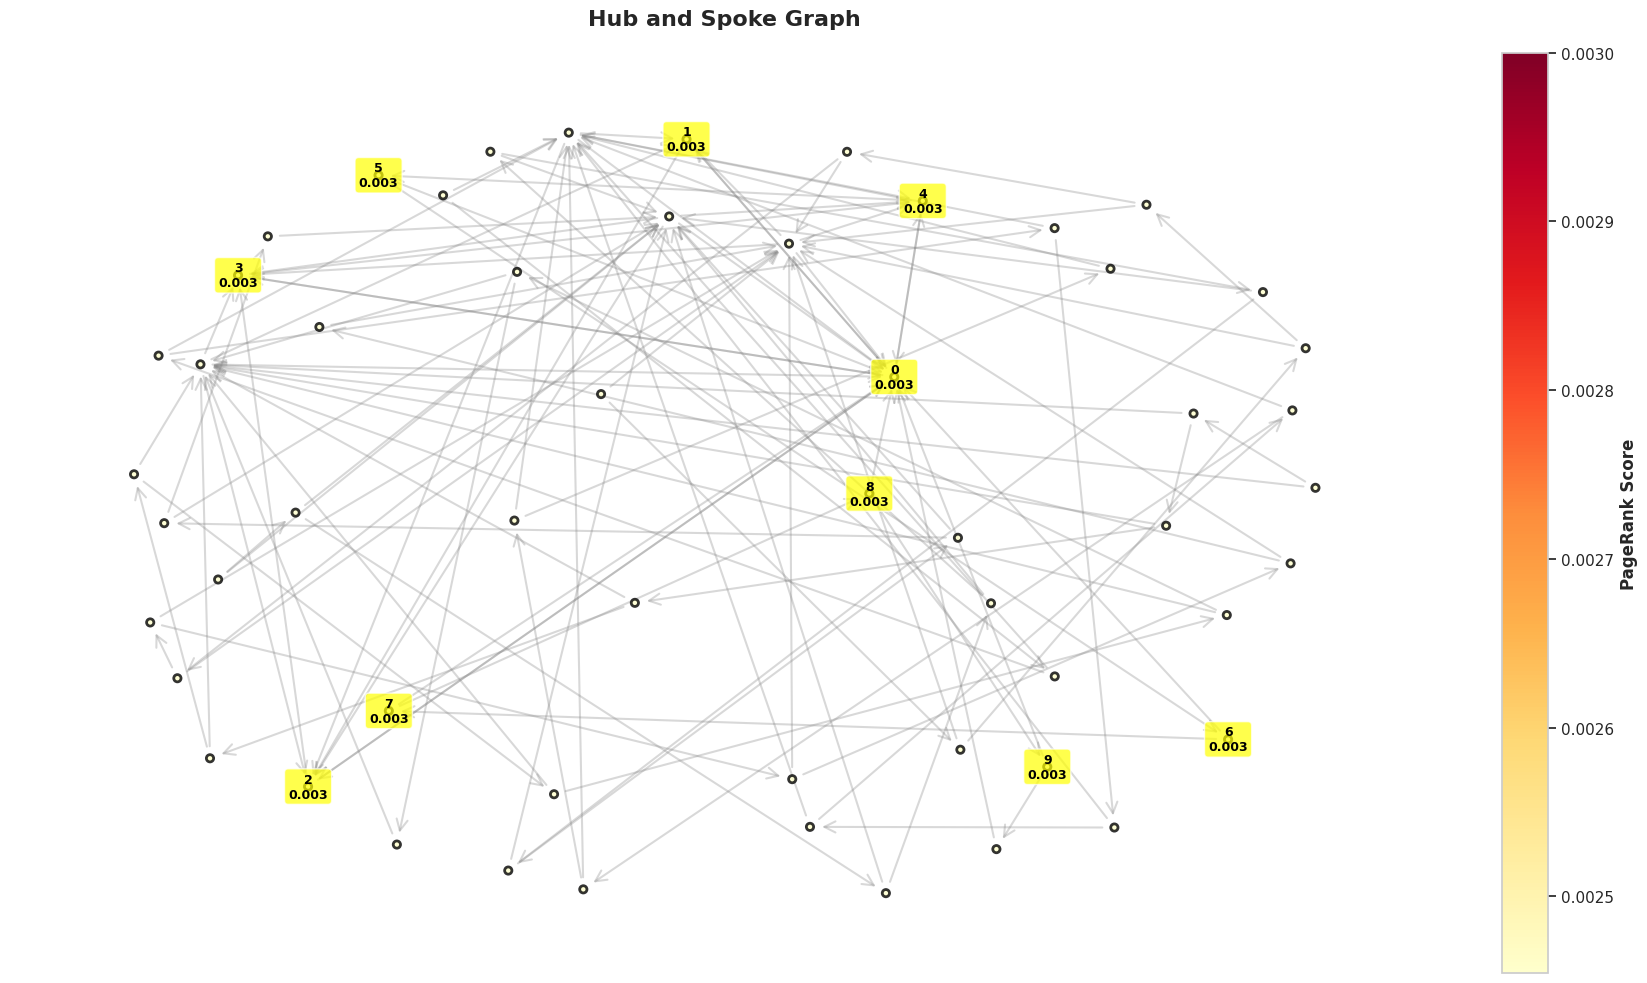



👥 ПРИКЛАД 2: Соціальна мережа (100 користувачів)
--------------------------------------------------------------------------------

🚀 ЗАПУСК BSP PAGERANK
  Вузлів: 100
  Ребер: 558
  Воркерів: 4
  Макс. supersteps: 20

  🔷 Worker 1: відповідає за 25 вузлів: [16, 24, 17, 90, 44]...
  🔷 Worker 3: відповідає за 25 вузлів: [43, 49, 61, 47, 60]...
  🔷 Worker 0: відповідає за 25 вузлів: [10, np.int64(5), np.int64(0), np.int64(9), np.int64(6)]...
  🔷 Worker 2: відповідає за 25 вузлів: [26, 62, 53, 27, 79]...
  📊 Superstep 5 завершено
  📊 Superstep 10 завершено
  📊 Superstep 15 завершено
  📊 Superstep 20 завершено
  🏁 Worker 0: BSP обчислення завершено

✅ BSP PAGERANK ЗАВЕРШЕНО
  Загальний час: 3758.00 мс


🏆 ТОП-10 СТОРІНОК ЗА PAGERANK
Позиція    ID вузла        PageRank        %         
------------------------------------------------------------
🥇 #1       10              0.001500        1.00      %
🥈 #2       5               0.001500        1.00      %
🥉 #3       0               0.001500

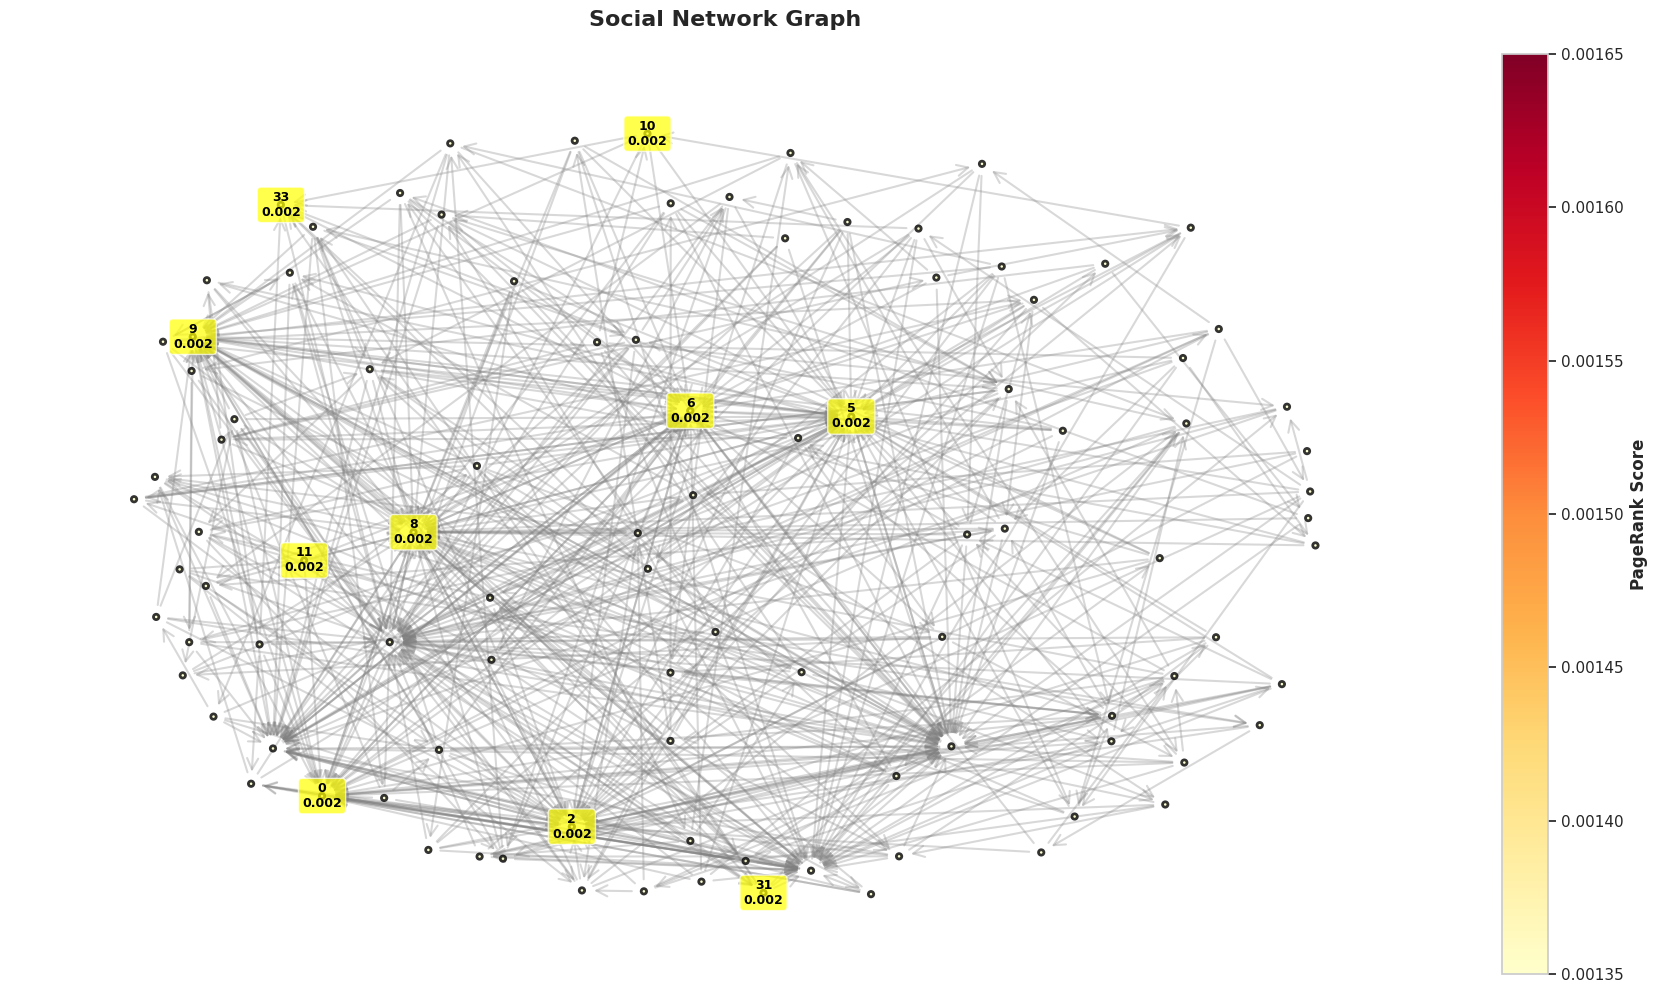



🌐 ПРИКЛАД 3: Випадковий веб-граф (500 сторінок)
--------------------------------------------------------------------------------

🚀 ЗАПУСК BSP PAGERANK
  Вузлів: 500
  Ребер: 4959
  Воркерів: 4
  Макс. supersteps: 20

  🔷 Worker 1: відповідає за 125 вузлів: [251, 268, 326, 368, 411]...
  🔷 Worker 3: відповідає за 125 вузлів: [244, 449, 330, 69, 353]...
  🔷 Worker 0: відповідає за 125 вузлів: [0, 73, 129, 172, 206]...
  🔷 Worker 2: відповідає за 125 вузлів: [32, 33, 360, 373, 380]...
  📊 Superstep 5 завершено
  📊 Superstep 10 завершено
  📊 Superstep 15 завершено
  📊 Superstep 20 завершено
  🏁 Worker 0: BSP обчислення завершено

✅ BSP PAGERANK ЗАВЕРШЕНО
  Загальний час: 23461.25 мс


🏆 ТОП-15 СТОРІНОК ЗА PAGERANK
Позиція    ID вузла        PageRank        %         
------------------------------------------------------------
🥇 #1       0               0.000300        0.20      %
🥈 #2       73              0.000300        0.20      %
🥉 #3       129             0.000300        0.20     

In [14]:
# test_bsp_pagerank.py

import multiprocessing as mp
from src.algorithms.bsp_pagerank import (
    create_web_graph,
    create_hub_and_spoke_graph,
    create_social_network_graph,
    visualize_pagerank,
    print_top_pages,
    BSPConfig
)

if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)
    
    print("\n" + "="*80)
    print("🌐 ДЕМОНСТРАЦІЯ BSP (Bulk Synchronous Parallel) МОДЕЛІ")
    print("   Задача: PageRank для аналізу важливості веб-сторінок")
    print("="*80)
    
    # ========================================================================
    # Приклад 1: Маленький Hub-and-Spoke граф (для розуміння)
    # ========================================================================
    print("\n\n📍 ПРИКЛАД 1: Hub-and-Spoke граф (5 хабів, по 10 спиць)")
    print("-"*80)
    
    pagerank1 = create_hub_and_spoke_graph(num_hubs=5, spokes_per_hub=10)
    ranks1, time1 = pagerank1.run()
    print_top_pages(ranks1, top_n=10)
    
    # Візуалізація
    visualize_pagerank(pagerank1, ranks1, "Hub and Spoke Graph")
    
    # ========================================================================
    # Приклад 2: Соціальна мережа
    # ========================================================================
    print("\n\n👥 ПРИКЛАД 2: Соціальна мережа (100 користувачів)")
    print("-"*80)
    
    pagerank2 = create_social_network_graph(num_users=100)
    ranks2, time2 = pagerank2.run()
    print_top_pages(ranks2, top_n=10)
    
    visualize_pagerank(pagerank2, ranks2, "Social Network Graph")
    
    # ========================================================================
    # Приклад 3: Великий веб-граф
    # ========================================================================
    print("\n\n🌐 ПРИКЛАД 3: Випадковий веб-граф (500 сторінок)")
    print("-"*80)
    
    pagerank3 = create_web_graph(num_pages=500, edge_probability=0.02)
    ranks3, time3 = pagerank3.run()
    print_top_pages(ranks3, top_n=15)
    
    # ========================================================================
    # Порівняння продуктивності
    # ========================================================================
    print("\n\n" + "="*80)
    print("⚡ ПОРІВНЯННЯ ПРОДУКТИВНОСТІ")
    print("="*80)
    
    import pandas as pd
    
    results = pd.DataFrame([
        {
            'Граф': 'Hub-and-Spoke',
            'Вузлів': len(pagerank1.graph),
            'Ребер': sum(len(n.outgoing_edges) for n in pagerank1.graph.values()),
            'Час (мс)': time1,
            'Топ вузол': max(ranks1, key=ranks1.get),
            'Топ ранг': max(ranks1.values())
        },
        {
            'Граф': 'Соціальна мережа',
            'Вузлів': len(pagerank2.graph),
            'Ребер': sum(len(n.outgoing_edges) for n in pagerank2.graph.values()),
            'Час (мс)': time2,
            'Топ вузол': max(ranks2, key=ranks2.get),
            'Топ ранг': max(ranks2.values())
        },
        {
            'Граф': 'Веб-граф',
            'Вузлів': len(pagerank3.graph),
            'Ребер': sum(len(n.outgoing_edges) for n in pagerank3.graph.values()),
            'Час (мс)': time3,
            'Топ вузол': max(ranks3, key=ranks3.get),
            'Топ ранг': max(ranks3.values())
        }
    ])
    
    print("\n")
    print(results.to_string(index=False))
    
    # ========================================================================
    # Пояснення BSP моделі
    # ========================================================================
    print("\n\n" + "="*80)
    print("📚 ЯК ПРАЦЮЄ BSP (Bulk Synchronous Parallel)?")
    print("="*80)
    print("""
    BSP модель складається з послідовності СУПЕР-КРОКІВ (supersteps).
    Кожен супер-крок має 3 фази:
    
    1️⃣  LOCAL COMPUTATION (Локальні обчислення)
       • Кожен worker обчислює нові PageRank значення для своїх вузлів
       • Використовує дані з ПОПЕРЕДНЬОГО супер-кроку
       • Не залежить від інших workers - паралельно!
    
    2️⃣  COMMUNICATION (Комунікація)
       • Workers відправляють повідомлення іншим workers
       • У PageRank: відправляємо частину рангу сусіднім вузлам
       • Повідомлення будуть доставлені до НАСТУПНОГО супер-кроку
    
    3️⃣  BARRIER SYNCHRONIZATION (Синхронізація)
       • Всі workers чекають один одного
       • Гарантує, що всі завершили обчислення та комунікацію
       • Тільки після цього починається наступний супер-крок
    
    ⚡ ПЕРЕВАГИ BSP:
       ✅ Простота програмування (чіткі фази)
       ✅ Детермінованість (однакові результати при повтореннях)
       ✅ Легко аналізувати складність
       ✅ Добре масштабується
    
    🎯 ЗАСТОСУВАННЯ:
       • Graph алгоритми (PageRank, shortest paths)
       • Machine Learning (gradient descent)
       • Scientific simulations
       • Big Data processing
    """)
    print("="*80)
    
    print("\n✅ Демонстрація завершена!")

## + Actor Model

In [15]:
!python src/algorithms/actor_framework.py

2025-10-10 17:21:04,486	INFO worker.py:1951 -- Started a local Ray instance.
🍽️  РЕСТОРАН 'Actor Model' ВІДКРИВАЄТЬСЯ


👥 Створюємо персонал...

✅ Персонал готовий до роботи!

(Waiter pid=1918776) 🙋 Олег прийняв замовлення від столика #1
(Waiter pid=1918776)    Страви: Борщ, Вареники, Компот
(Chef pid=1918775) 👨‍🍳 Іван почав готувати Борщ (замовлення #1)
(Chef pid=1918774) 👨‍🍳 Ольга почав готувати Вареники (замовлення #1)
(Chef pid=1918952) 👨‍🍳 Петро почав готувати Компот (замовлення #1)
(OrderManager pid=1918953) 
(OrderManager pid=1918953) 📋 Менеджер обробляє замовлення #1
(Waiter pid=1918776) 🙋 Олег прийняв замовлення від столика #2
(Waiter pid=1918776)    Страви: Салат Цезар, Стейк
(OrderManager pid=1918953) 
(OrderManager pid=1918953) 📋 Менеджер обробляє замовлення #2
(Waiter pid=1918773) 🙋 Марія прийняв замовлення від столика #3
(Waiter pid=1918773)    Страви: Піца Маргарита, Тірамісу, Капучино
(OrderManager pid=1918953) 
(OrderManager pid=1918953) 📋 Менеджер обробляє замовлення 

## + MPI

In [13]:
# !pip install mpi4py
!sudo apt-get install libopenmpi-dev openmpi-bin -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  autoconf automake autotools-dev gfortran gfortran-13
  gfortran-13-x86-64-linux-gnu gfortran-x86-64-linux-gnu libamd-comgr2
  libamdhip64-5 libcaf-openmpi-3t64 libcoarrays-dev libcoarrays-openmpi-dev
  libevent-2.1-7t64 libevent-dev libevent-extra-2.1-7t64
  libevent-openssl-2.1-7t64 libevent-pthreads-2.1-7t64 libfabric1
  libgfortran-13-dev libgfortran5 libhsa-runtime64-1 libhsakmt1 libhwloc-dev
  libhwloc-plugins libhwloc15 libibverbs-dev libjs-jquery-ui libllvm17t64
  libltdl-dev libmunge2 libnl-3-dev libnl-route-3-dev libnuma-dev
  libopenmpi3t64 libpmix-dev libpmix2t64 libpsm-infinipath1 libpsm2-2
  librdmacm1t64 libtool libucx0 libxnvctrl0 m4 ocl-icd-libopencl1
  openmpi-common
Suggested packages:
  autoconf-archive gnu-standards autoconf-doc gettext gfortran-multilib
  gfortran-doc gfortran-13-multilib gfortran-13-doc libhwloc-co

In [15]:
# RUN as system root ⚠️
# ! mpiexec -n 4 python src/algorithms/mpi.py


#### 🎯 Ключові концепції MPI в прикладі:

##### 1. **Broadcast** (один → всі)
```python
comm.bcast(config, root=0)
```
- Master відправляє конфігурацію **всім** процесам одночасно

##### 2. **Scatter** (розподіл даних)
```python
my_chunk = comm.scatter(chunks, root=0)
```
- Master **розподіляє** дані між worker-процесами
- Кожен worker отримує свій чанк

##### 3. **Gather** (збір результатів)
```python
all_results = comm.gather(my_results, root=0)
```
- Worker-процеси **повертають** результати master-процесу
- Master збирає всі результати в один список

##### 4. **Point-to-Point** (Send/Recv)
```python
comm.send(message, dest=worker_rank, tag=11)
response = comm.recv(source=0, tag=22)
```
- Пряма комунікація між конкретними процесами



#### Запуск:
```bash
# Запустити з 4 процесами (1 master + 3 workers)
mpiexec -n 4 python mpi_weather.py

# Або з 6 процесами для більшого паралелізму
mpiexec -n 6 python mpi_weather.py
```


#### 💡 Переваги MPI (які видно в прикладі):

| Особливість | Опис |
|-------------|------|
| **Справжній паралелізм** | Кожен процес працює на окремому CPU ядрі |
| **Розподілена пам'ять** | Процеси не діляться пам'яттю (безпечно) |
| **Масштабованість** | Легко розширити до сотень машин (HPC кластери) |
| **Ефективність** | Мінімальні накладні витрати на комунікацію |

#### 🆚 MPI vs Actor Model (Ray):

| Характеристика | MPI | Actor Model (Ray) |
|----------------|-----|-------------------|
| **Парадигма** | Процеси + повідомлення | Об'єкти + методи |
| **Комунікація** | Явна (Send/Recv) | Неявна (.remote()) |
| **Використання** | HPC, наукові обчислення | Web-сервіси, ML, загальні задачі |
| **Складність** | Складніше (low-level) | Простіше (high-level) |
| **Розподіл даних** | Ручний (Scatter/Gather) | Автоматичний |

